# Import Table

In [5]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.act1  = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.shortcut = None
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        self.act2 = nn.SiLU()

    def forward(self, x):
        identity = x
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.act2(self.bn2(self.conv2(out)))
        if self.shortcut is not None:
            identity = self.shortcut(x)
        return out + identity



class DeepTileEncoder(nn.Module):
    """Deepened Tile Branching:Global Information,Multi-Scale Pooling + Three-Layer MLP"""
    def __init__(self, out_dim, in_channels=3, negative_slope=0.01):
        super().__init__()
        self.layer0 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(2)  # 78→39
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 64),
            ResidualBlock(64, 64),
            nn.MaxPool2d(2)  # 39→19
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128),
            ResidualBlock(128, 128),
            nn.MaxPool2d(2)  # 19→9
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256),
            ResidualBlock(256, 256)
        ) 

        # Multi-scale pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # [B,256,1,1]
        self.mid_pool    = nn.AdaptiveAvgPool2d((3, 3))  # [B,256,3,3]

        total_dim = 256*1*1 + 256*3*3
        # Three layered MLP：total_dim → 2*out_dim → out_dim → out_dim
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(total_dim, out_dim*4),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim*4, out_dim*2),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim*2, out_dim),
            nn.LeakyReLU(negative_slope),
        )

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        # x: [B,256,9,9]
        g = self.global_pool(x).contiguous().reshape(x.size(0), -1)  # [B,256]
        m = self.mid_pool(x).contiguous().reshape(x.size(0), -1)     # [B,256*3*3]

        return self.fc(torch.cat([g, m], dim=1))


class SubtileEncoder(nn.Module):
    """Multi Scale Subtile Branching:Local Information + Two Layer MLP"""
    def __init__(self, out_dim, in_channels=3, negative_slope=0.01):
        super().__init__()
        self.layer0 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(2)  # 26→13
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 64),
            ResidualBlock(64, 64),
            nn.MaxPool2d(2)  # 13→6
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128),
            ResidualBlock(128, 128)
        )  

        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        self.mid_pool    = nn.AdaptiveAvgPool2d((2,2))
        self.large_pool    = nn.AdaptiveAvgPool2d((3,3))

        total_dim = 128*1*1 + 128*2*2 + 128*3*3
        # Two Layer MLP：total_dim → out_dim*2 → out_dim
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(total_dim, out_dim*2),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim*2, out_dim),
            nn.LeakyReLU(negative_slope),
        )

    def forward(self, x):
        B, N, C, H, W = x.shape
        x = x.contiguous().reshape(B*N, C, H, W)
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        # g,m: [B*N, feat]
        g = self.global_pool(x).contiguous().reshape(B, N, -1)
        m = self.mid_pool(x).contiguous().reshape(B, N, -1)
        l = self.large_pool(x).contiguous().reshape(B, N, -1)

        # Merge subtiles，then FC
        feat = torch.cat([g, m, l], dim=2).mean(dim=1).contiguous()  # [B, total_dim]
        return self.fc(feat)
class CenterSubtileEncoder(nn.Module):
    """A dedicated subtile Encoder for processing centers"""
    def __init__(self, out_dim, in_channels=3, negative_slope= 0.01):
        super().__init__()
        self.layer0 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(2)  # 26→13
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 64),
            ResidualBlock(64, 64),
            nn.MaxPool2d(2)  # 13→6
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128),
            ResidualBlock(128, 128)
        )  # 6×6

        # Multi-Scale Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        self.mid_pool    = nn.AdaptiveAvgPool2d((2,2))
        self.large_pool    = nn.AdaptiveAvgPool2d((3,3))

        total_dim = 128*1*1 + 128*2*2 + 128*3*3
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(total_dim, out_dim*2),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim*2, out_dim),
            nn.LeakyReLU(negative_slope),
        )

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        g = self.global_pool(x).contiguous().reshape(x.size(0), -1)
        m = self.mid_pool(x).contiguous().reshape(x.size(0), -1)
        l = self.large_pool(x).contiguous().reshape(x.size(0), -1)

        return self.fc(torch.cat([g, m, l], dim=1)).contiguous()



class VisionMLP_MultiTask(nn.Module):
    """Overall Multi-Task Model:Merging tile + subtile + center using dynamic weights"""
    def __init__(self, tile_dim=128, subtile_dim=64, output_dim=35, negative_slope=0.01):
        super().__init__()
        self.encoder_tile    = DeepTileEncoder(tile_dim)
        self.encoder_subtile = SubtileEncoder(subtile_dim)
        self.encoder_center  = CenterSubtileEncoder(subtile_dim)

        # Output decoder：Input is tile_dim (because after merging only a vector remains)
        self.decoder = nn.Sequential(
            nn.Linear(tile_dim + subtile_dim + subtile_dim , 256),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(64, output_dim),
        )

    def forward(self, tile, subtiles):
        tile = tile.contiguous()
        subtiles = subtiles.contiguous()
        center = subtiles[:, 4]

        f_tile = self.encoder_tile(tile)         # [B, tile_dim]
        f_sub  = self.encoder_subtile(subtiles)  # [B, subtile_dim]
        f_center = self.encoder_center(center)   # [B, subtile_dim]

        # Gating by splicing3 branches
        features_cat = torch.cat([f_tile, f_sub, f_center], dim=1)  # [B, tile+sub+center]
        return self.decoder(features_cat)






model = VisionMLP_MultiTask(tile_dim=128, subtile_dim=128, output_dim=35)


# —— 5) Ensure that only the decoder can be trained 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable / total params = {trainable:,} / {total:,}")

Trainable / total params = 6,679,843 / 6,679,843


## Load Model ##

#### Import training data

In [6]:
import os
import torch
import random
import inspect
import sys
sys.path.append("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project")
from scripts.import_data import load_all_tile_data


folder = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Final_preprocessing\\train_data"

grouped_data = load_all_tile_data( 
        folder_path=folder,
        model=model,
        fraction=1,
        shuffle=False
    )

    # grouped_data will now only contain the keys needed by model.forward() 
    # ['tile','subtiles','neighbors','norm_coord','node_feat','adj_list','edge_feat','label','source_idx']
print("Loaded keys:", grouped_data.keys())
print("Samples:", len(next(iter(grouped_data.values()))))

Loaded keys: dict_keys(['slide_idx', 'subtiles', 'source_idx', 'label', 'tile', 'position'])
Samples: 8348


In [ ]:
import os
import torch
import csv
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
from scripts.operate_model import train_one_epoch, evaluate, predict, plot_losses, plot_per_cell_metrics,spear_EarlyStopping
import torch.nn as nn

# ---------------------------
# Your save_folder path for the plots and model
# ---------------------------
save_folder = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\Plots_Models"  
if not os.path.exists(save_folder):   
    os.makedirs(save_folder)

In [14]:
# --------------------------------------------
# 2) Retrieve slide_idx from grouped_data and convert it to numpy
# --------------------------------------------
import numpy as np
slide_idx = np.array(grouped_data['slide_idx'])   # shape (N,)

# --------------------------------------------
# 3) Create a LOGO（or change it to GroupKFold）
# --------------------------------------------
from sklearn.model_selection import LeaveOneGroupOut
logo = LeaveOneGroupOut()

# X can be a virtual matrix because grouping only relies on groups
X_dummy = np.zeros(len(slide_idx))
X_dummy

array([0., 0., 0., ..., 0., 0., 0.], shape=(8348,))

EarlyStopping counter: 10/10
[Epoch 14]  lr=5.53e-04, train_loss=37.8950, val_loss=65.5275
train spearman: 0.8003 | Val spearman: 0.6132 | best: 0.6630


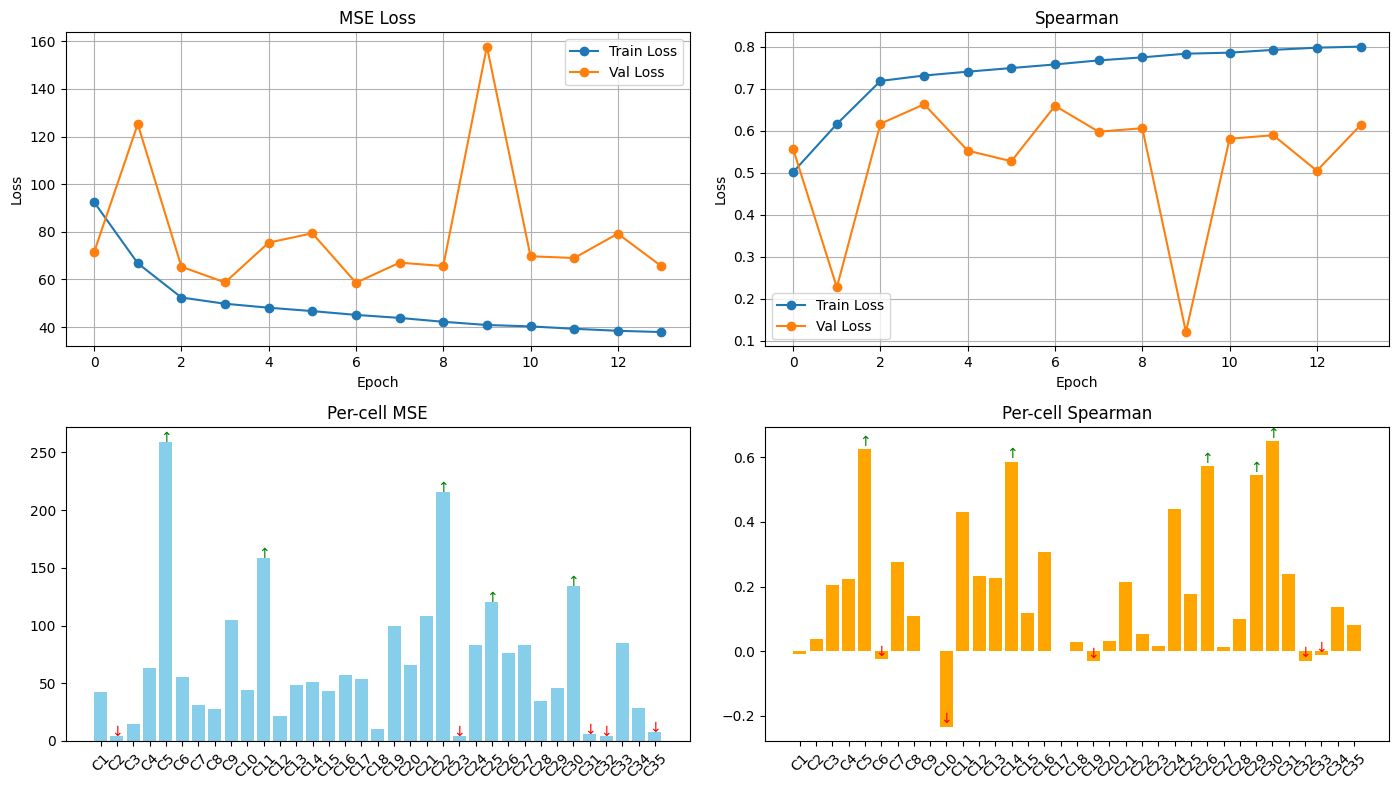

<Figure size 640x480 with 0 Axes>

save plots in C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\Plots_Models\fold5\loss_curve.png
⛔ early stop
📈 Fold 5 best ρ = 0.6630

=========== CV summary ===========
fold 0: best ρ = 0.6892
fold 1: best ρ = 0.7280
fold 2: best ρ = 0.6983
fold 3: best ρ = 0.5145
fold 4: best ρ = 0.5394
fold 5: best ρ = 0.6630
overall best (mean) ρ = 0.6387 ± 0.0816


In [5]:
from torch.utils.data import DataLoader
from scripts.import_data import importDataset
from scripts.aug import augment_grouped_data, identity, subset_grouped_data
import math
from torch.optim.lr_scheduler import LambdaLR
# ---------------- Params ----------------
start_fold = 0   # Start training from which fold 0-based），Folds smaller than this value will be skipped

BATCH_SIZE   = 32
num_epochs   = 150
repeats      = 0
# ---------------- Param settings ----------------
save_root    = save_folder          # outermost layer
os.makedirs(save_root, exist_ok=True)

# Seed once at the very top for reproducibility

logo     = LeaveOneGroupOut()
device   = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("✅ device:", device)

overall_best = []
# At the head of your script file



# ➋ LOGO / GroupKFold This is a partitioning index used to create a Subset within a Dataset
for fold_id, (tr_idx, va_idx) in enumerate(
        logo.split(X=np.zeros(len(slide_idx)), y=None, groups=slide_idx)):
    
        # Skip if current fold < start_fold
    if fold_id < start_fold:
        print(f"⏭️ Skipping fold {fold_id}")
        continue
    
    print("Starting fold", fold_id)
    print("Starting subseting...")

    train_base = subset_grouped_data(grouped_data, tr_idx)
    print("Starting augmenting...")

    train_ds = augment_grouped_data(
                    grouped_data=train_base,
                    image_keys=['tile','subtiles'],
                    repeats=repeats   # Perform augmentation twice on each image
                )
    print("Starting importDataset...")
    # 1) Original dataset
    train_ds = importDataset(train_ds, model,
                            image_keys=['tile','subtiles'],
                            transform=identity)


    # 3) validation raw
    val_ds     = subset_grouped_data(grouped_data, va_idx)
    val_ds     = importDataset(val_ds, model,
                            image_keys=['tile','subtiles'],
                            transform=identity)

    print("Starting DataLoader...")
    # 4) DataLoader will no longer be dynamically enhanced
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=False)

    # 5) All other steps are the same as before: define the model,optimizer,train one epoch,evaluate

    print("Starting model...")
    # ----- Create a new model/optimizer -----
    net = VisionMLP_MultiTask(tile_dim=128, subtile_dim=128, output_dim=35)

    net = net.to(device)

    # We replace the original Adam with AdamW，and add a slight weight decay
    peak_lr       = 1e-3
    min_lr        = 1e-6
    warmup_epochs = 0
    total_epochs  = 30

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, net.parameters()),
        lr=peak_lr, weight_decay=1e-3
    )

    # lr_lambda
    def lr_lambda(cur_epoch):
        if cur_epoch < warmup_epochs:
            # Linear warm-up: 0 → 1
            return float(cur_epoch + 1) / warmup_epochs
        else:
            # Cosine annealing：from 1 → min_lr/peak_lr
            progress = (cur_epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            # cos(0)=1 → cos(pi)=−1, remap to [min_ratio,1]
            min_ratio = min_lr / peak_lr
            return min_ratio + 0.5 * (1 - min_ratio) * (1 + math.cos(math.pi * progress))

    scheduler = LambdaLR(optimizer, lr_lambda)

    stopper = spear_EarlyStopping(patience=10)

    # ----- fold's output path -----
    fold_dir  = os.path.join(save_folder, f"fold{fold_id}")
    os.makedirs(fold_dir, exist_ok=True)
    best_model_path = os.path.join(fold_dir, "best_model.pt")
    loss_plot_path  = os.path.join(fold_dir, "loss_curve.png")
    csv_path        = os.path.join(fold_dir, "training_log.csv")

    # ----- CSV log -----
    log_f = open(csv_path, "w", newline="")
    csv_w = csv.writer(log_f)
    csv_w.writerow(["Epoch","TrainLoss","ValLoss","ValSpearman","LR"])

    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    display(fig)

    train_losses = []; val_losses = []
    train_rhos   = []; val_rhos   = []

    best_rho = -1.0
    print("Starting training...")
    for epoch in range(num_epochs):

        tloss, trho = train_one_epoch(
            net, train_loader, optimizer, device,
            current_epoch=epoch, initial_alpha=0, final_alpha=0, target_epoch=20 )

        vloss, vrho, mse_cell, rho_cell = evaluate(
            net, val_loader, device,
            current_epoch=epoch, initial_alpha=0, final_alpha=0, target_epoch=20 )

        clear_output(wait=True)  # Clear previous output
        axes[0][0].clear()
        axes[0][1].clear()
        axes[1][0].clear()
        axes[1][1].clear()
        # --- save best ---
        if vrho > best_rho:
            best_rho = vrho
            torch.save(net.state_dict(), best_model_path)
            print(f"✅ Saved best model in {best_model_path}!")

        # --- scheduler / early stop ---
        scheduler.step()
        stopper(vrho)


    
        # --- logging ---
        lr = optimizer.param_groups[0]['lr']
        csv_w.writerow([epoch+1, tloss, vloss, vrho, lr])

        train_losses.append(tloss); val_losses.append(vloss)
        train_rhos.append(trho);   val_rhos.append(vrho)
        

        

        # Print out Epoch results
        lr = optimizer.param_groups[0]['lr']
        print(f"[Epoch {epoch+1}]  lr={lr:.2e}, train_loss={tloss:.4f}, val_loss={vloss:.4f}")
        print(f"train spearman: {trho:.4f} | Val spearman: {vrho:.4f} | best: {best_rho:.4f}")
        # --- update plots ---
        plot_losses(train_losses, val_losses, axes[0][0], "MSE Loss")
        plot_losses(train_rhos,   val_rhos,   axes[0][1], "Spearman")
        cell_names = [f"C{i+1}" for i in range(35)]
        plot_per_cell_metrics(mse_cell, rho_cell, cell_names,
                              ax_mse=axes[1][0], ax_spearman=axes[1][1])
        plt.tight_layout(); display(fig); plt.pause(0.1)
        fig.savefig(loss_plot_path)
        print(f"save plots in {loss_plot_path}")
        if stopper.early_stop:
            print("⛔ early stop"); break

    log_f.close(); plt.close(fig)
    overall_best.append(best_rho) 
    print(f"📈 Fold {fold_id} best ρ = {best_rho:.4f}")

# ========= Overall results =========
overall_best = np.array(overall_best)
print("\n=========== CV summary ===========")
for i, r in enumerate(overall_best):
    print(f"fold {i}: best ρ = {r:.4f}")
print(f"overall best (mean) ρ = {overall_best.mean():.4f} ± {overall_best.std():.4f}")

### Predict

In [7]:
import torch
import inspect
import importlib
import scripts.import_data

importlib.reload(scripts.import_data)
from scripts.operate_model import get_model_inputs
from scripts.import_data import load_node_feature_data
from scripts.import_data import importDataset
# Assuming your model has already been defined and instantiated as 'model'
test_dataset = load_node_feature_data("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\data_preprocessing\\Final_preprocessing\\test_data\\test_dataset.pt", model)
test_dataset = importDataset(
        data_dict=test_dataset,
        model=model,
        image_keys=['tile','subtiles'],
        transform=lambda x: x,  # identity transform
        print_sig=True
    )

Inferring the sample size from'<class 'list'>': 2088
Model forward signature: (tile, subtiles)


In [11]:
import glob
import torch
import numpy as np
import pandas as pd
import os
import h5py
from torch.utils.data import DataLoader

#  test spot index
with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5","r") as f:
    test_spots     = f["spots/Test"]
    test_spot_table= pd.DataFrame(np.array(test_spots['S_7']))

fold_ckpts = sorted(glob.glob(os.path.join(save_folder, "fold*", "best_model.pt")))
models = []
for ckpt in fold_ckpts:
    net = VisionMLP_MultiTask(tile_dim=128, subtile_dim=128, output_dim=35)
    net = net.to(device)
    net.load_state_dict(torch.load(ckpt, map_location="cpu"))
    net.to(device).eval()
    models.append(net)

all_fold_preds = []
for fold_id, net in enumerate(models):
    
    with torch.no_grad():
        preds = predict(net, test_loader, device)  # (N_test,35) numpy array

    # 1) Save the original prediction for each fold
    df_fold = pd.DataFrame(preds, columns=[f"C{i+1}" for i in range(preds.shape[1])])
    df_fold.insert(0, "ID", test_spot_table.index)
    path_fold = os.path.join(save_folder, f"submission_fold{fold_id}.csv")
    df_fold.to_csv(path_fold, index=False)
    print(f"✅ Saved fold {fold_id} predictions to {path_fold}")

    all_fold_preds.append(preds)

# 2)  rank‐average ensemble
all_fold_preds = np.stack(all_fold_preds, axis=0)       # (K, N_test, 35)
ranks          = all_fold_preds.argsort(axis=2).argsort(axis=2).astype(float)
mean_rank      = ranks.mean(axis=0)                    # (N_test,35)

# 3)  final ensemble
df_ens = pd.DataFrame(mean_rank, columns=[f"C{i+1}" for i in range(mean_rank.shape[1])])
df_ens.insert(0, "ID", test_spot_table.index)
path_ens = os.path.join(save_folder, "submission_rank_ensemble.csv")
df_ens.to_csv(path_ens, index=False)
print(f" Saved rank‐ensemble submission to {path_ens}")

✅ Saved fold 0 predictions to C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\Plots_Models\submission_fold0.csv
✅ Saved fold 1 predictions to C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\Plots_Models\submission_fold1.csv
✅ Saved fold 2 predictions to C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\Plots_Models\submission_fold2.csv
✅ Saved fold 3 predictions to C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\Plots_Models\submission_fold3.csv
✅ Saved fold 4 predictions to C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\Plots_Models\submission_fold4.csv
✅ Saved fold 5 predictions to C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\Plots_Models\submission_fold5.csv
 Saved rank‐ensemble submission to C:\Users\saura\OneDrive\Desktop\4th year\BM616\Project\Plots_Models\submission_rank_ensemble.csv


In [9]:
from torch.utils.data import DataLoader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 6 Models Stacking

In [11]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project")
from scripts.import_data import importDataset  # Assuming this gives you full_dataset
from scripts.aug import subset_grouped_data   # Used to extract grouped_data
from torch.utils.data import DataLoader, Subset

# Settings
full_dataset = importDataset(grouped_data, model,
                             image_keys=['tile','subtiles'],
                             transform=lambda x: x)
save_folder = "C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\Plots_Models"
trained_oof_model_folder = save_folder
n_folds    = 6
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
C          = 35  # Number of categories / Length of each prediction vector
META_EPOCHS = 250
tile_dim = 128
center_dim = 128
neighbor_dim = 128
# 1) Load full_dataset & y_true
n_samples = len(full_dataset)
y_true = np.vstack([full_dataset[i]['label'].cpu().numpy() for i in range(n_samples)])

In [16]:
from sklearn.model_selection import LeaveOneGroupOut
logo = LeaveOneGroupOut()
# 2) Collect OOF predictions for each fold
oof_preds = np.zeros((n_samples, n_folds, C), dtype=np.float32)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=False)

for fold_id, (_, va_idx) in enumerate(
    logo.split(X=np.zeros(n_samples), y=None, groups=slide_idx)
):
    # a) load base model for this fold
    print(f" Fold {fold_id} predicting ...")
    ckpt = os.path.join(trained_oof_model_folder, f"fold{fold_id}", "best_model.pt")
    net  = VisionMLP_MultiTask(tile_dim, center_dim, output_dim=C).to(device)
    net.load_state_dict(torch.load(ckpt, map_location=device))
    net.eval()
    
    # b) Use this model to make predictions only on its **validation set**（OOF）
    val_ds = Subset(full_dataset, va_idx)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    preds_list = []
    with torch.no_grad():
        for batch in full_loader:
            tiles, subtiles = batch['tile'].to(device), batch['subtiles'].to(device)
            center = subtiles[:,4]
            f_c = net.encoder_center(center)
            f_n = net.encoder_subtile(subtiles)
            f_t = net.encoder_tile(tiles)
            fuse = torch.cat([f_c,f_n,f_t], dim=1)
            out = net.decoder(fuse)
            preds_list.append(out.cpu().numpy())
    preds_fold = np.concatenate(preds_list, axis=0)  # (len(va_idx), C)

    # c) Fill in the missing data back into oof_preds[:, fold_id, :]
    oof_preds[:, fold_id, :] = preds_fold

print(" Preparing data for meta model ...")

# 3) reshape → stacking feature matrix X_stack
X_stack = oof_preds.reshape(n_samples, n_folds*C)    # (N, n_folds*C)
y_stack = y_true                                   # (N, C)

# 4) Divide meta‐train / meta‐val
X_train, X_val, y_train, y_val = train_test_split(
    X_stack, y_stack, test_size=0.2, random_state=42, shuffle=True
)

# 5) DataLoader
ds_train = TensorDataset(torch.from_numpy(X_train).float(),
                         torch.from_numpy(y_train).float())
ds_val   = TensorDataset(torch.from_numpy(X_val).float(),
                         torch.from_numpy(y_val).float())
loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)

# 6) Define stacking MLP
in_dim = n_folds * C
class StackingMLP(nn.Module):
    def __init__(self, in_dim, hidden_dims=[512,256], out_dim=35, dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.LeakyReLU(0.01))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.Dropout(dropout))
            prev = h
        # The last layer directly outputs out_dim
        layers.append(nn.Linear(prev, out_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        """
        x: Tensor of shape [B, in_dim], in_dim = n_folds * C
        returns: Tensor of shape [B, out_dim]
        """
        return self.model(x)

mlp = StackingMLP(in_dim=n_folds*C, hidden_dims=[512,256], out_dim=C).to(device)

optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6)
criterion = nn.MSELoss()

best_val = float('inf')
es_cnt, es_patience = 0, 20
best_path = os.path.join(trained_oof_model_folder, "stacking_meta_best.pt")

print(" Start training meta model ...")

# 7) Training loop
for epoch in range(1, META_EPOCHS+1):
    mlp.train()
    train_loss = 0.0
    for xb, yb in loader_train:
        xb, yb = xb.to(device), yb.to(device)
        out = mlp(xb)               # Forward
        loss = criterion(out, yb)   # MSE
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(ds_train)

    # Verify
    mlp.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader_val:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(mlp(xb), yb).item() * xb.size(0)
    val_loss /= len(ds_val)


    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch} — Train MSE {train_loss:.6f}, Val MSE {val_loss:.6f}, lr {current_lr:.3e}")
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != current_lr:
        print(f"LR reduced from {current_lr:.2e} → {new_lr:.2e}")

    if val_loss < best_val:
        best_val = val_loss; es_cnt = 0
        torch.save(mlp.state_dict(), best_path)
        print(" ↳ New best saved.")
    else:
        es_cnt += 1
        if es_cnt >= es_patience:
            print(" Early stopping.")
            break

# 8)Load back from the best model
mlp.load_state_dict(torch.load(best_path, map_location=device))
mlp.eval()

 Fold 0 predicting ...
 Fold 1 predicting ...
 Fold 2 predicting ...
 Fold 3 predicting ...
 Fold 4 predicting ...
 Fold 5 predicting ...
 Preparing data for meta model ...
 Start training meta model ...
Epoch 1 — Train MSE 388.216003, Val MSE 319.038195, lr 1.000e-03
 ↳ New best saved.
Epoch 2 — Train MSE 212.013520, Val MSE 137.362326, lr 1.000e-03
 ↳ New best saved.
Epoch 3 — Train MSE 58.261333, Val MSE 58.844920, lr 1.000e-03
 ↳ New best saved.
Epoch 4 — Train MSE 44.023950, Val MSE 41.314616, lr 1.000e-03
 ↳ New best saved.
Epoch 5 — Train MSE 42.747921, Val MSE 41.264940, lr 1.000e-03
 ↳ New best saved.
Epoch 6 — Train MSE 42.281229, Val MSE 60.366711, lr 1.000e-03
Epoch 7 — Train MSE 41.789573, Val MSE 57.531001, lr 1.000e-03
Epoch 8 — Train MSE 41.650593, Val MSE 48.070722, lr 1.000e-03
Epoch 9 — Train MSE 41.112337, Val MSE 44.929113, lr 1.000e-03
Epoch 10 — Train MSE 40.833204, Val MSE 60.855119, lr 1.000e-03
Epoch 11 — Train MSE 40.547772, Val MSE 53.979132, lr 1.000e-03
Ep

StackingMLP(
  (model): Sequential(
    (0): Linear(in_features=210, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=35, bias=True)
  )
)

In [19]:
import h5py
import pandas as pd
# --- Testing phase：stacking features + one mlp.forward() ---
# Make predictions for each fold in the test set，construct oof_preds_test (n_test, n_folds, C),and reshape → (n_test, n_folds*C)
oof_test = np.zeros((len(test_dataset), n_folds, C), dtype=np.float32)
for fold_id in range(n_folds):
    print(f" Fold {fold_id} predicting ...")
    # load each base model & predict on full test_dataset
    ckpt = os.path.join(trained_oof_model_folder, f"fold{fold_id}", "best_model.pt")
    net  = VisionMLP_MultiTask(tile_dim, center_dim, output_dim=C).to(device)
    net.load_state_dict(torch.load(ckpt, map_location=device))
    net.eval()

    loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    preds_list = []
    with torch.no_grad():
        for batch in loader:
            tiles, subtiles = batch['tile'].to(device), batch['subtiles'].to(device)
            center = subtiles[:,4]
            fuse = torch.cat([
                net.encoder_center(center),
                net.encoder_subtile(subtiles),
                net.encoder_tile(tiles)
            ], dim=1)
            preds_list.append(net.decoder(fuse).cpu().numpy())
    oof_test[:, fold_id, :] = np.concatenate(preds_list, axis=0)

print(" Meta model predicting ...")
X_test_stack = oof_test.reshape(len(test_dataset), n_folds*C)
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test_stack).float().to(device)
    final_test_preds = mlp(X_test_t).cpu().numpy()

# 9) 存 submission
with h5py.File("C:\\Users\\saura\\OneDrive\\Desktop\\4th year\\BM616\\Project\\el-hackathon-2025\\elucidata_ai_challenge_data.h5","r") as f:
    ids = pd.DataFrame(np.array(f["spots/Test"]["S_7"])).index
sub = pd.DataFrame(final_test_preds, columns=[f"C{i+1}" for i in range(C)])
sub.insert(0, 'ID', ids)
sub.to_csv(os.path.join(trained_oof_model_folder, "submission_stacked_single_mlp.csv"), index=False)
print("✅ Done single‐MLP stacking submission.")

 Fold 0 predicting ...
 Fold 1 predicting ...
 Fold 2 predicting ...
 Fold 3 predicting ...
 Fold 4 predicting ...
 Fold 5 predicting ...
 Meta model predicting ...
✅ Done single‐MLP stacking submission.
